# =========================================================
# HOUSE PRICE PREDICTION - COMPLETE ML PIPELINE
# REGRESSION PROBLEM
# =========================================================

# Dataset:
# House Prices Dataset from Kaggle
#
# File:
# train.csv
#
# Goal:
# Predict SalePrice using house features
# =========================================================

# 1. IMPORT LIBRARIES

In [1]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")



# 2. DATA GATHERING

In [2]:
# =========================================================
# 2. DATA GATHERING
# =========================================================

# Read CSV file
df = pd.read_csv("data/houseprice/train.csv")

print("=" * 50)
print("FIRST 5 ROWS")
print("=" * 50)

print(df.head())



FIRST 5 ROWS
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008

# 3. BASIC DATA UNDERSTANDING

In [3]:
# =========================================================
# 3. BASIC DATA UNDERSTANDING
# =========================================================

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nDATA TYPES")
print(df.dtypes)

print("\nDATASET INFO")
print(df.info())

print("\nSTATISTICAL SUMMARY")
print(df.describe())




DATASET SHAPE
(1460, 81)

COLUMN NAMES
Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'Garag

# 4. MISSING VALUES

In [4]:
# =========================================================
# 4. MISSING VALUES
# =========================================================

print("\nMISSING VALUES")

missing_values = df.isnull().sum()

print(
    missing_values[
        missing_values > 0
    ].sort_values(ascending=False)
)




MISSING VALUES
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


# 5. TARGET VARIABLE ANALYSIS

In [5]:
# =========================================================
# 5. TARGET VARIABLE ANALYSIS
# =========================================================

print("\nTARGET VARIABLE")

print(df["SalePrice"].head())




TARGET VARIABLE
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


# EDA - EXPLORATORY DATA ANALYSIS

In [6]:
# =========================================================
# =========================================================
# EDA - EXPLORATORY DATA ANALYSIS
# =========================================================
# =========================================================


# 6. UNIVARIATE ANALYSIS

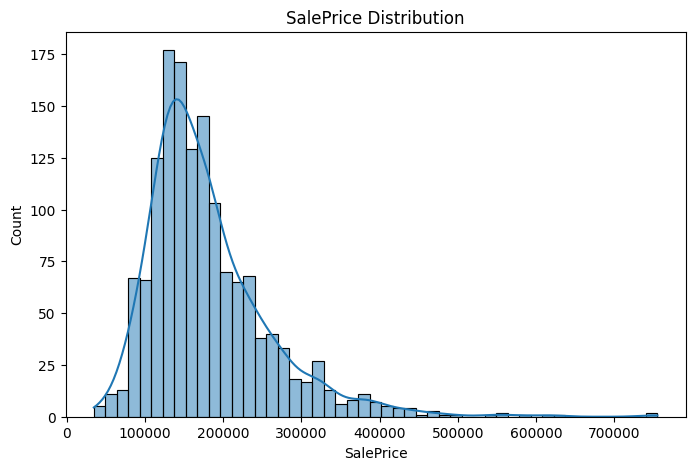

In [7]:
# =========================================================
# 6. UNIVARIATE ANALYSIS
# TARGET DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["SalePrice"],
    kde=True
)

plt.title("SalePrice Distribution")

plt.show()



# 7. SKEWNESS CHECK

In [8]:
# =========================================================
# 7. SKEWNESS CHECK
# =========================================================

saleprice_skew = skew(df["SalePrice"])

print("\nSALE PRICE SKEWNESS")
print(saleprice_skew)




SALE PRICE SKEWNESS
1.880940746034036


# 8. LOG TRANSFORMATION

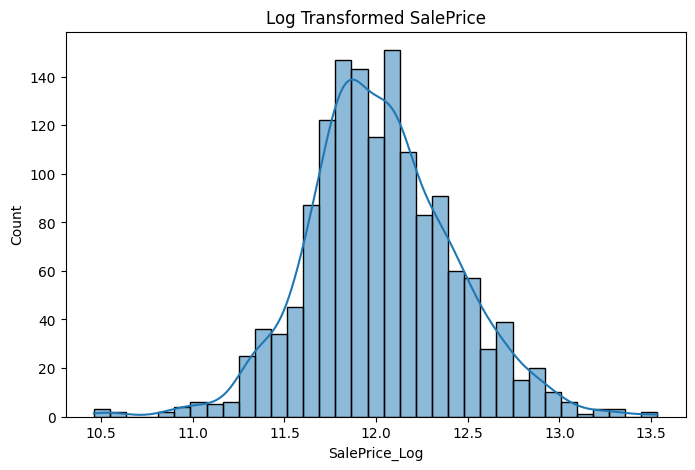

In [9]:
# =========================================================
# 8. LOG TRANSFORMATION
# =========================================================

# Reduce skewness
df["SalePrice_Log"] = np.log1p(df["SalePrice"])

plt.figure(figsize=(8,5))

sns.histplot(
    df["SalePrice_Log"],
    kde=True
)

plt.title("Log Transformed SalePrice")

plt.show()


# 9. BOXPLOT - OUTLIER DETECTION

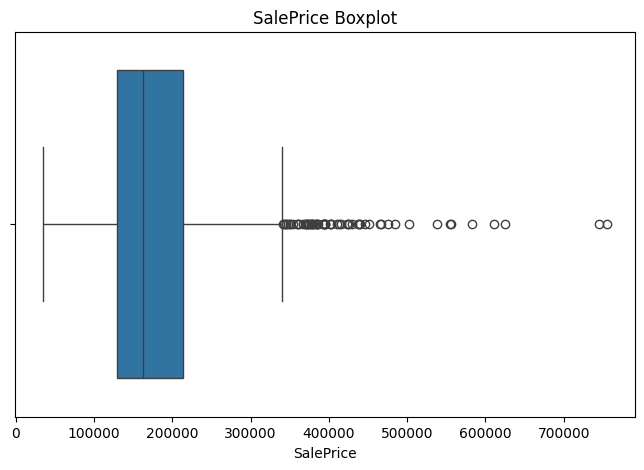

In [10]:
# =========================================================
# 9. BOXPLOT - OUTLIER DETECTION
# =========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["SalePrice"]
)

plt.title("SalePrice Boxplot")

plt.show()



# 10. NUMERICAL FEATURE DISTRIBUTION

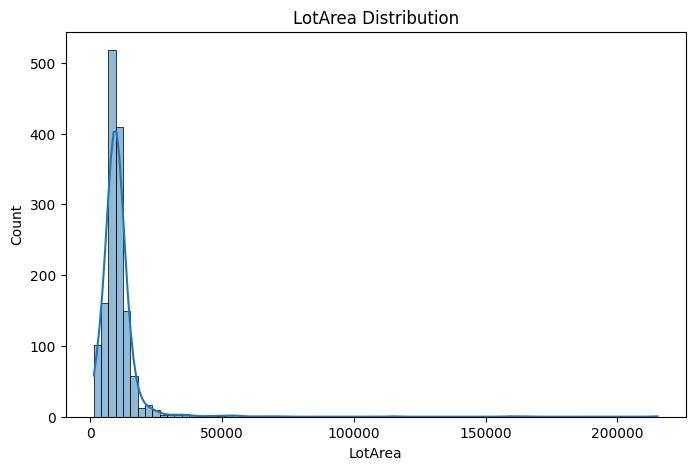

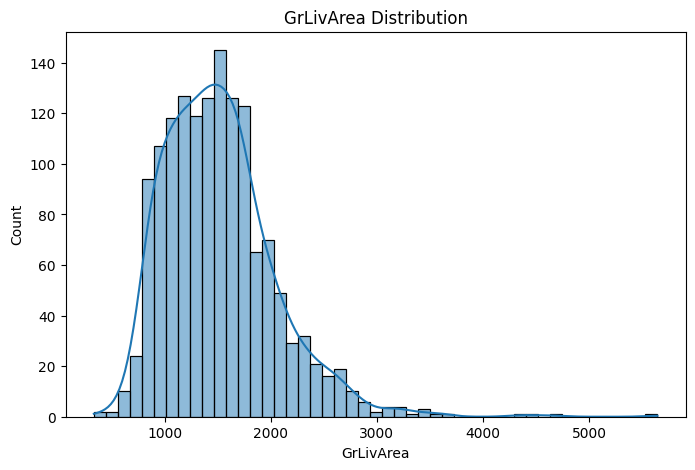

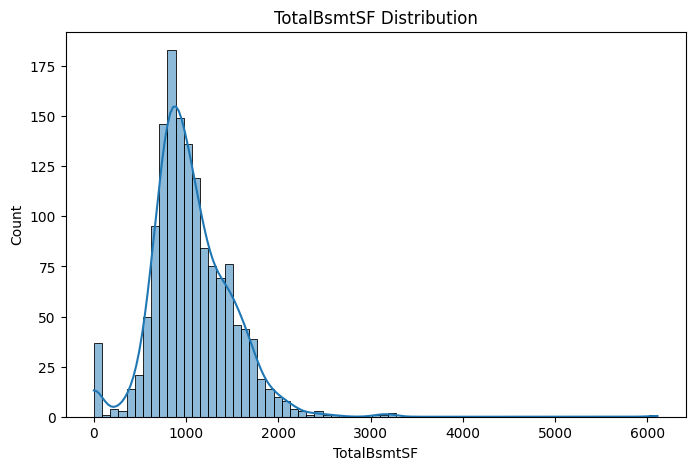

In [11]:
# =========================================================
# 10. NUMERICAL FEATURE DISTRIBUTION
# =========================================================

numerical_columns = [
    "LotArea",
    "GrLivArea",
    "TotalBsmtSF"
]

for col in numerical_columns:

    plt.figure(figsize=(8,5))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f"{col} Distribution")

    plt.show()




# 11. CATEGORICAL FEATURE ANALYSIS

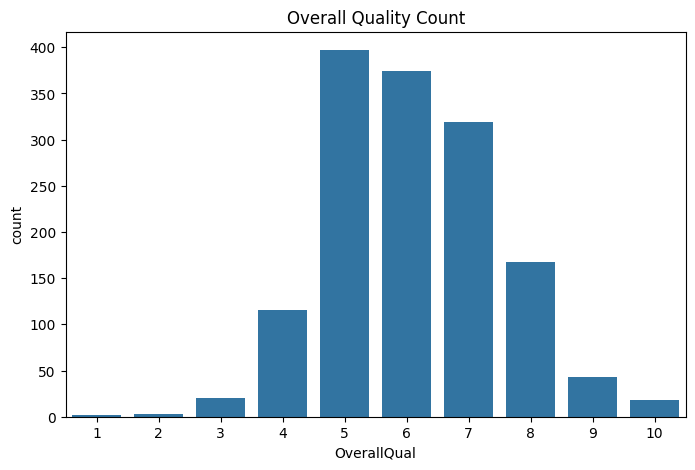

In [12]:
# =========================================================
# 11. CATEGORICAL FEATURE ANALYSIS
# =========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x="OverallQual",
    data=df
)

plt.title("Overall Quality Count")

plt.show()



# MULTIVARIATE ANALYSIS

In [13]:
# =========================================================
# =========================================================
# MULTIVARIATE ANALYSIS
# =========================================================
# =========================================================


# 12. SCATTER PLOT

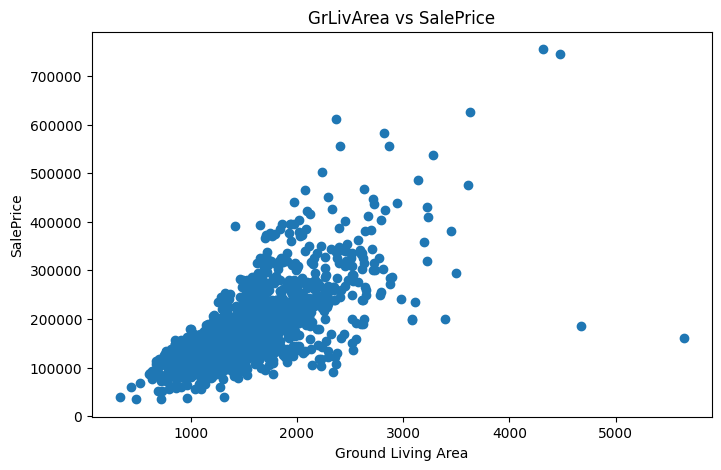

In [14]:
# =========================================================
# 12. SCATTER PLOT
# =========================================================

plt.figure(figsize=(8,5))

plt.scatter(
    df["GrLivArea"],
    df["SalePrice"]
)

plt.xlabel("Ground Living Area")

plt.ylabel("SalePrice")

plt.title("GrLivArea vs SalePrice")

plt.show()



# 13. CORRELATION HEATMAP

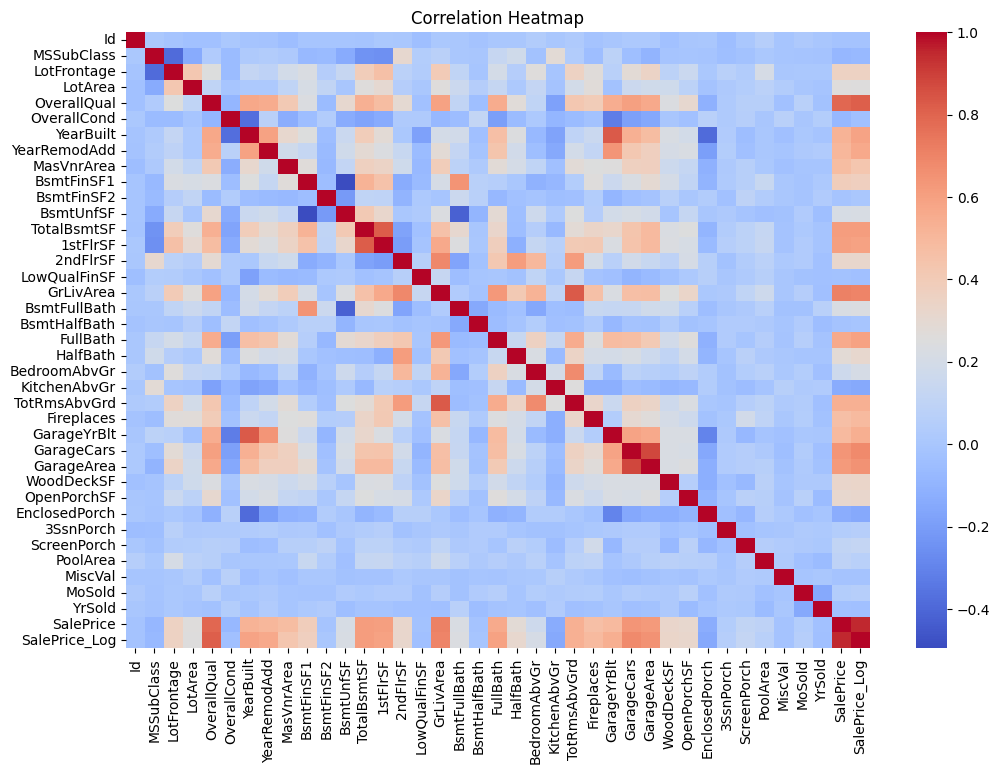

In [15]:
# =========================================================
# 13. CORRELATION HEATMAP
# =========================================================

plt.figure(figsize=(12,8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()



# 14. TOP CORRELATED FEATURES

In [16]:
# =========================================================
# 14. TOP CORRELATED FEATURES
# =========================================================

correlation = corr_matrix["SalePrice"].sort_values(
    ascending=False
)

print("\nTOP CORRELATED FEATURES")

print(correlation.head(10))




TOP CORRELATED FEATURES
SalePrice        1.000000
SalePrice_Log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
Name: SalePrice, dtype: float64


# 15. PAIRPLOT

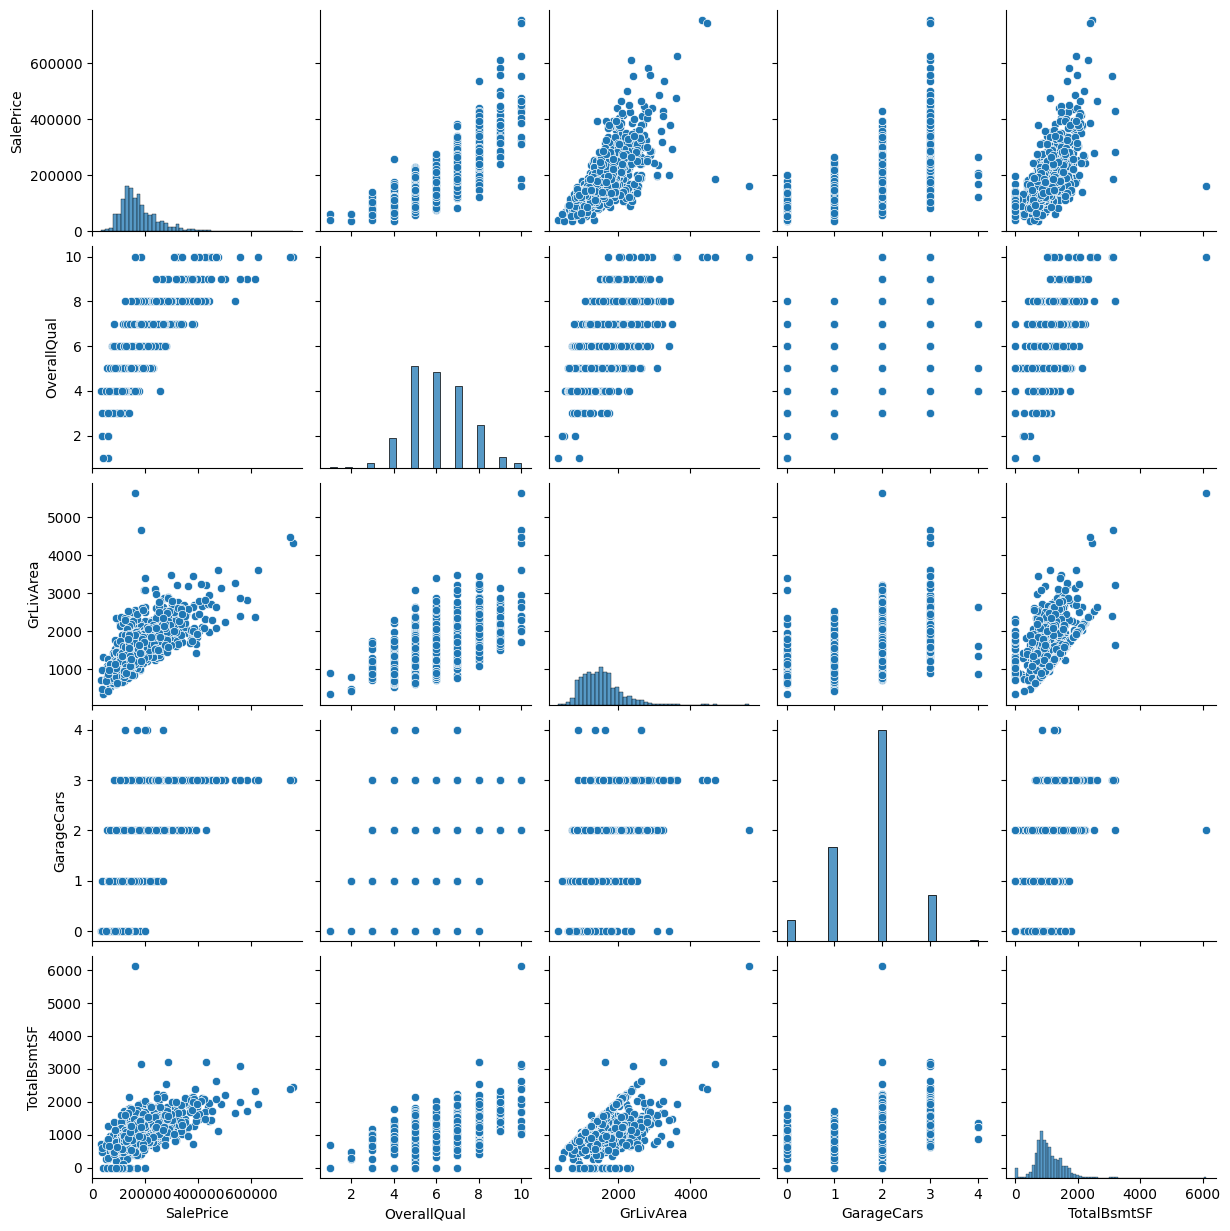

In [17]:
# =========================================================
# 15. PAIRPLOT
# =========================================================

important_cols = [
    "SalePrice",
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF"
]

sns.pairplot(
    df[important_cols]
)

plt.show()



# 16. BOXPLOT

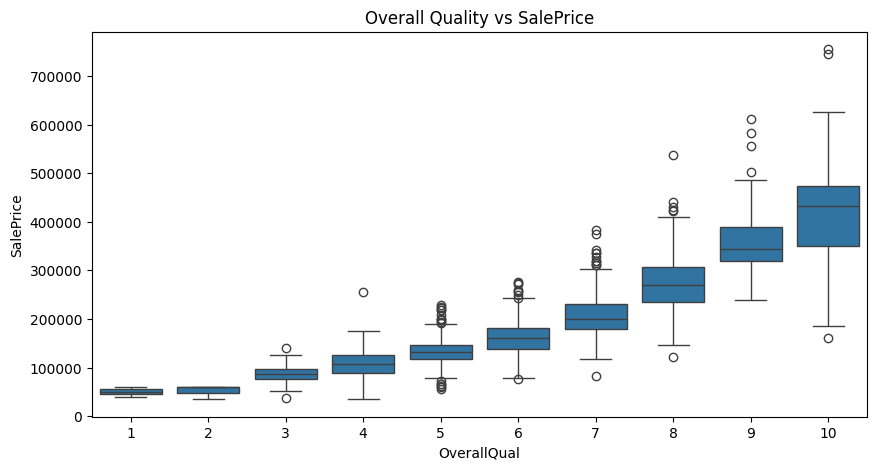

In [18]:
# =========================================================
# 16. BOXPLOT
# =========================================================

plt.figure(figsize=(10,5))

sns.boxplot(
    x="OverallQual",
    y="SalePrice",
    data=df
)

plt.title("Overall Quality vs SalePrice")

plt.show()



# FEATURE ENGINEERING

In [19]:
# =========================================================
# =========================================================
# FEATURE ENGINEERING
# =========================================================
# =========================================================


# 17. FEATURE CONSTRUCTION

In [20]:
# =========================================================
# 17. FEATURE CONSTRUCTION
# =========================================================

# Create new feature
df["HouseAge"] = 2025 - df["YearBuilt"]

print("\nNEW FEATURE - HouseAge")

print(df["HouseAge"].head())




NEW FEATURE - HouseAge
0     22
1     49
2     24
3    110
4     25
Name: HouseAge, dtype: int64


# 18. FEATURE SELECTION

In [21]:
# =========================================================
# 18. FEATURE SELECTION
# =========================================================

selected_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "YearBuilt",
    "HouseAge",
    "Neighborhood"
]

target = "SalePrice_Log"

X = df[selected_features]

y = df[target]



# 19. HANDLE MISSING VALUES

In [22]:
# =========================================================
# 19. HANDLE MISSING VALUES
# =========================================================

print("\nMISSING VALUES BEFORE")

print(X.isnull().sum())




MISSING VALUES BEFORE
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
FullBath        0
YearBuilt       0
HouseAge        0
Neighborhood    0
dtype: int64


# 20. NUMERICAL/CATEGORICAL FEATURES

In [23]:
# =========================================================
# 20. NUMERICAL/CATEGORICAL FEATURES
# =========================================================

numerical_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "YearBuilt",
    "HouseAge"
]

categorical_features = [
    "Neighborhood"
]


# 21. OUTLIER DETECTION - IQR METHOD

In [24]:
# =========================================================
# 21. OUTLIER DETECTION - IQR METHOD
# =========================================================

Q1 = df["GrLivArea"].quantile(0.25)

Q3 = df["GrLivArea"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

print("\nOUTLIER LIMITS")

print(lower_limit, upper_limit)


# Remove outliers
df = df[
    (df["GrLivArea"] >= lower_limit) &
    (df["GrLivArea"] <= upper_limit)
]

print("\nSHAPE AFTER OUTLIER REMOVAL")

print(df.shape)




OUTLIER LIMITS
158.625 2747.625

SHAPE AFTER OUTLIER REMOVAL
(1429, 83)


# 22. FEATURE SCALING

In [25]:
# =========================================================
# 22. FEATURE SCALING
# =========================================================

# Standard Scaler
standard_scaler = StandardScaler()

scaled_standard = standard_scaler.fit_transform(
    df[numerical_features]
)

print("\nSTANDARD SCALED DATA")

print(scaled_standard[:5])


# MinMax Scaler
minmax_scaler = MinMaxScaler()

scaled_minmax = minmax_scaler.fit_transform(
    df[numerical_features]
)

print("\nMINMAX SCALED DATA")

print(scaled_minmax[:5])


# Robust Scaler
robust_scaler = RobustScaler()

scaled_robust = robust_scaler.fit_transform(
    df[numerical_features]
)

print("\nROBUST SCALED DATA")

print(scaled_robust[:5])




STANDARD SCALED DATA
[[ 0.70146892  0.5185942   0.33270886 -0.45839268  0.85755778  1.05818913
  -1.05818913]
 [-0.04049932 -0.47746912  0.33270886  0.54258785  0.85755778  0.15642857
  -0.15642857]
 [ 0.70146892  0.68756923  0.33270886 -0.30060264  0.85755778  0.99139206
  -0.99139206]
 [ 0.70146892  0.53415769  1.68339341 -0.70493961 -1.02196686 -1.88088234
   1.88088234]
 [ 1.44343715  1.60359175  1.68339341  0.25412795  0.85755778  0.95799352
  -0.95799352]]

MINMAX SCALED DATA
[[0.66666667 0.57429048 0.5        0.26699938 0.66666667 0.94927536
  0.05072464]
 [0.55555556 0.38731219 0.5        0.39363693 0.66666667 0.75362319
  0.24637681]
 [0.66666667 0.60601002 0.5        0.28696195 0.66666667 0.93478261
  0.06521739]
 [0.66666667 0.57721202 0.75       0.23580786 0.33333333 0.3115942
  0.6884058 ]
 [0.77777778 0.77796327 0.75       0.35714286 0.66666667 0.92753623
  0.07246377]]

ROBUST SCALED DATA
[[ 0.5         0.41545894  0.         -0.26569038  0.          0.67391304
  -0.673

# 23. COLUMN TRANSFORMER

In [26]:
# =========================================================
# 23. COLUMN TRANSFORMER
# =========================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)



# 24. TRAIN TEST SPLIT

In [27]:
# =========================================================
# 24. TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTRAIN SHAPE")

print(X_train.shape)

print("\nTEST SHAPE")

print(X_test.shape)




TRAIN SHAPE
(1168, 8)

TEST SHAPE
(292, 8)


# MODEL BUILDING

In [28]:
# =========================================================
# =========================================================
# MODEL BUILDING
# =========================================================
# =========================================================


# 25. CREATE PIPELINE

In [29]:
# =========================================================
# 25. CREATE PIPELINE
# =========================================================

model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "regressor",
            LinearRegression()
        )
    ]
)



# 26. TRAIN MODEL

In [30]:
# =========================================================
# 26. TRAIN MODEL
# =========================================================

model.fit(
    X_train,
    y_train
)

print("\nMODEL TRAINED")




MODEL TRAINED


# 27. PREDICTION

In [31]:
# =========================================================
# 27. PREDICTION
# =========================================================

y_pred = model.predict(X_test)

print("\nPREDICTIONS")

print(y_pred[:10])




PREDICTIONS
[11.83765195 12.64292048 11.64810595 11.97983038 12.60641991 11.26672342
 12.30365126 11.92332925 11.26261108 11.68896187]


# 28. EVALUATION METRICS

In [32]:
# =========================================================
# 28. EVALUATION METRICS
# =========================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("\nMAE")
print(mae)

print("\nMSE")
print(mse)

print("\nRMSE")
print(rmse)

print("\nR2 SCORE")
print(r2)




MAE
0.11299401013784832

MSE
0.025511900614151907

RMSE
0.15972445214854208

R2 SCORE
0.8632883261213725


# 29. ACTUAL VS PREDICTED

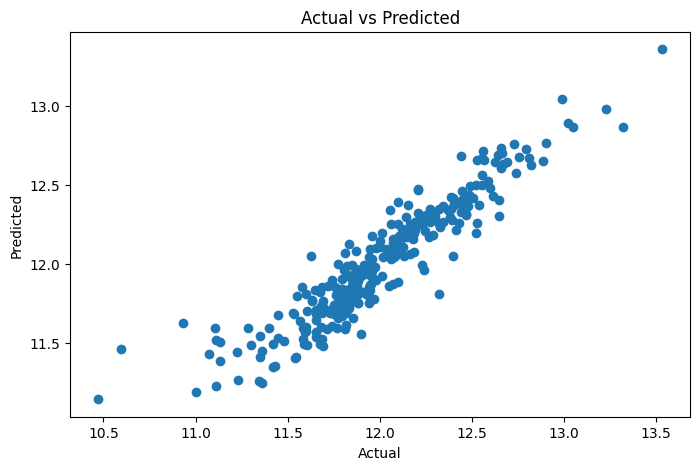

In [33]:
# =========================================================
# 29. ACTUAL VS PREDICTED
# =========================================================

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()



# 30. RESIDUAL ANALYSIS

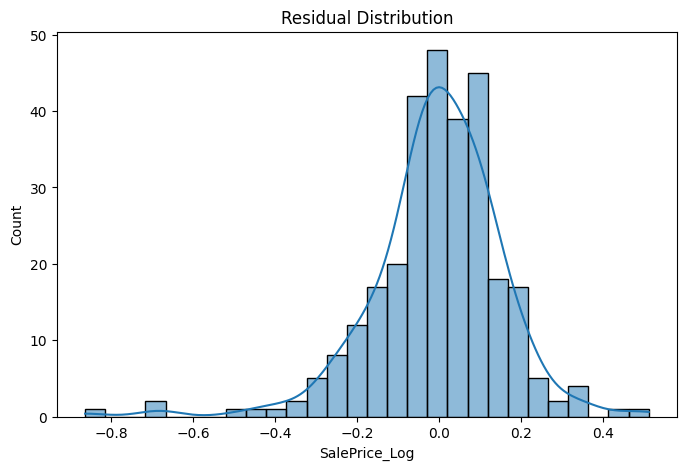

In [34]:
# =========================================================
# 30. RESIDUAL ANALYSIS
# =========================================================

residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()



# 31. RESIDUAL SCATTER PLOT

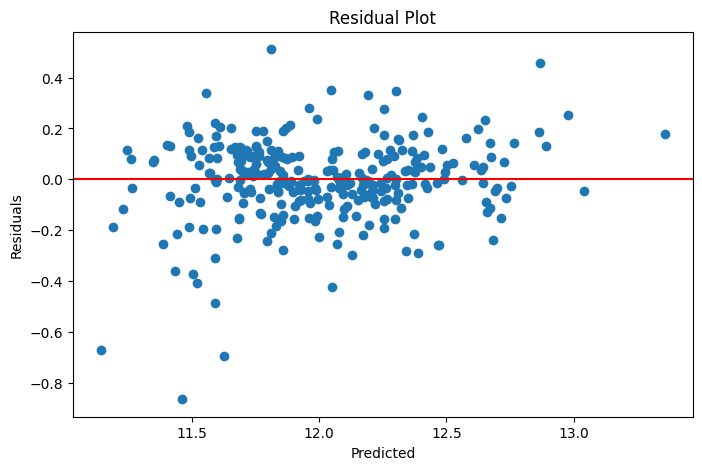

In [35]:
# =========================================================
# 31. RESIDUAL SCATTER PLOT
# =========================================================

plt.figure(figsize=(8,5))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()



# 32. SAMPLE PREDICTION

In [36]:
# =========================================================
# 32. SAMPLE PREDICTION
# =========================================================

sample_house = pd.DataFrame({

    "OverallQual": [7],
    "GrLivArea": [1700],
    "GarageCars": [2],
    "TotalBsmtSF": [900],
    "FullBath": [2],
    "YearBuilt": [2005],
    "HouseAge": [20],
    "Neighborhood": ["CollgCr"]

})

sample_prediction = model.predict(sample_house)

# Reverse log transformation
final_price = np.expm1(sample_prediction)

print("\nPREDICTED HOUSE PRICE")

print(final_price)




PREDICTED HOUSE PRICE
[207052.44157763]


# =====================================
# IMPORTANT CONCEPTS COVERED
# =====================================

"""
IMPORTANT CONCEPTS COVERED:

1. Regression Problem
2. Data Gathering
3. EDA
4. Univariate Analysis
5. Multivariate Analysis
6. Correlation Analysis
7. Feature Construction
8. Log Transformation
9. Outlier Detection
10. Scaling
11. ColumnTransformer
12. Pipelines
13. Linear Regression
14. Regression Metrics
15. Residual Analysis

NEW IMPORTANT CONCEPTS:

Log Transformation:
Used to reduce skewness

Residual:
Actual - Predicted

Correlation:
Relationship strength between variables

R2 Score:
Goodness of fit

RMSE:
Average prediction error magnitude

Feature Construction:
Creating new features from existing features
"""

# USE test.csv FOR FINAL PREDICTIONS on HOUSE PRICE DATASET

In [37]:
# =========================================================
# USE test.csv FOR FINAL PREDICTIONS
# HOUSE PRICE DATASET
# =========================================================

# test.csv does NOT contain SalePrice
# because it is used for prediction only

# We use:
# - trained model
# - same preprocessing pipeline
# - predict SalePrice for test data

# =========================================================

# 1. LOAD TEST DATA

In [38]:
# =========================================================
# 1. LOAD TEST DATA
# =========================================================

test_df = pd.read_csv("data/houseprice/test.csv")

print("=" * 50)
print("TEST DATA")
print("=" * 50)

print(test_df.head())


TEST DATA
     Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0  1461          20       RH         80.0    11622   Pave   NaN      Reg   
1  1462          20       RL         81.0    14267   Pave   NaN      IR1   
2  1463          60       RL         74.0    13830   Pave   NaN      IR1   
3  1464          60       RL         78.0     9978   Pave   NaN      IR1   
4  1465         120       RL         43.0     5005   Pave   NaN      IR1   

  LandContour Utilities  ... ScreenPorch PoolArea PoolQC  Fence MiscFeature  \
0         Lvl    AllPub  ...         120        0    NaN  MnPrv         NaN   
1         Lvl    AllPub  ...           0        0    NaN    NaN        Gar2   
2         Lvl    AllPub  ...           0        0    NaN  MnPrv         NaN   
3         Lvl    AllPub  ...           0        0    NaN    NaN         NaN   
4         HLS    AllPub  ...         144        0    NaN    NaN         NaN   

  MiscVal MoSold  YrSold  SaleType  SaleCondition  
0     

# 2. CREATE SAME FEATURE

In [39]:
# =========================================================
# 2. CREATE SAME FEATURE
# IMPORTANT:
# Feature engineering must match training data
# =========================================================

test_df["HouseAge"] = 2025 - test_df["YearBuilt"]


# 3. SELECT SAME FEATURES

In [40]:
# =========================================================
# 3. SELECT SAME FEATURES
# IMPORTANT:
# Must match training features exactly
# =========================================================

test_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "YearBuilt",
    "HouseAge",
    "Neighborhood"
]

X_test_final = test_df[test_features]



# 4. PREDICT USING TRAINED MODEL

In [41]:
# =========================================================
# 4. PREDICT USING TRAINED MODEL
# =========================================================

test_predictions_log = model.predict(X_test_final)



# 5. REVERSE LOG TRANSFORMATION

In [42]:

# =========================================================
# 5. REVERSE LOG TRANSFORMATION
# =========================================================

# During training:
# SalePrice_Log = log1p(SalePrice)

# Reverse:
# original price = expm1(log value)

test_predictions = np.expm1(
    test_predictions_log
)


# 6. CREATE SUBMISSION DATAFRAME

In [43]:
# =========================================================
# 6. CREATE SUBMISSION DATAFRAME
# =========================================================

submission = pd.DataFrame({

    "Id": test_df["Id"],

    "SalePrice": test_predictions

})



# 7. VIEW PREDICTIONS

In [44]:
# =========================================================
# 7. VIEW PREDICTIONS
# =========================================================

print("\nPREDICTIONS")

print(submission.head())




PREDICTIONS
     Id      SalePrice
0  1461  119630.554490
1  1462  148351.074454
2  1463  164748.710357
3  1464  179399.474079
4  1465  235668.523590


# 8. SAVE SUBMISSION FILE

In [45]:
# =========================================================
# 8. SAVE SUBMISSION FILE
# =========================================================

submission.to_csv(
    "data/houseprice/submission.csv",
    index=False
)

print("\nsubmission.csv CREATED")


submission.csv CREATED
